# **Tutorial 02 - Change of Basis**: Supplementary Interactive Material

-------------------------------------------------------------------------

In Tutorial 01 we treated a matrix as something we could add, invert and factor. Here we ask what a factorization *means* geometrically.

The two factorizations below share a shape:

$$ A = VBV^{-1} \qquad \text{and} \qquad A = PDP^{-1} $$

In each case the outer pair carries us into and back out of a different basis, while the middle matrix performs a simple action once we are in it. This is the idea the Singular Value Decomposition generalizes in Tutorial 05.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt


## Visualizing Similar Matrices:

Recall, that two matrices  A and B are similar if $\exists V,V^{-1} $ such that:

$$ A = VBV^{-1}$$

Let us consider the action of some matrix A, which shears our poor smiley face on a 45 degree diagonal. We will find a Similar matrix B, and show how with the right choices of $V$ and $V^{-1}$ the same action can be applied.

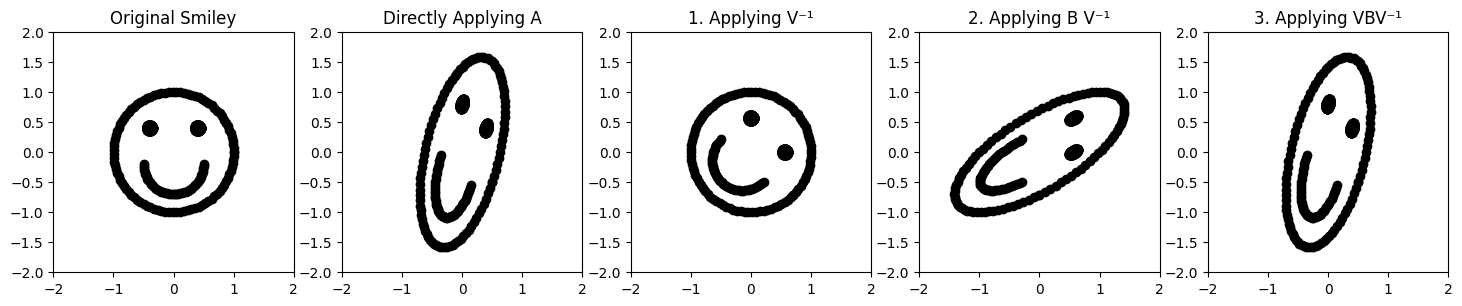

In [29]:
# --- Matrix Definitions ---
k = 1.0  # Shear factor
B = np.array([[1, k],
              [0, 1]])  # Shear along x-axis

theta = np.radians(45)  # Rotation angle
V = np.array([[np.cos(theta), -np.sin(theta)],
              [np.sin(theta),  np.cos(theta)]])
V_inv = V.T  # Since V is orthogonal, V⁻¹ = Vᵗ

# Compute A = VBV⁻¹
A = V @ B @ V_inv

# --- Smiley Face Point Cloud ---
t = np.linspace(0, 2 * np.pi, 100)

# Face outline (circle)
face_x = np.cos(t)
face_y = np.sin(t)

# Left Eye
left_eye_x = -0.4 + 0.05 * np.cos(t)
left_eye_y =  0.4 + 0.05 * np.sin(t)

# Right Eye
right_eye_x = 0.4 + 0.05 * np.cos(t)
right_eye_y = 0.4 + 0.05 * np.sin(t)

# Smile (arc)
smile_t = np.linspace(0, np.pi, 50)
smile_x = 0.5 * np.cos(smile_t)
smile_y = -0.5 * np.sin(smile_t) - 0.2

# Combine into single (N,2) array
points = np.vstack((
    np.column_stack((face_x, face_y)),
    np.column_stack((left_eye_x, left_eye_y)),
    np.column_stack((right_eye_x, right_eye_y)),
    np.column_stack((smile_x, smile_y))
))

# --- Apply Transformations ---
points_A = (A @ points.T).T
points_Vinv = (V_inv @ points.T).T
points_Vinv_B = (B @ points_Vinv.T).T
points_Vinv_B_V = (V @ points_Vinv_B.T).T

# --- Plotting ---
fig, axes = plt.subplots(1, 5, figsize=(18, 6))

titles = ["Original Smiley", "Directly Applying A", "1. Applying V⁻¹", "2. Applying B V⁻¹", "3. Applying VBV⁻¹"]
point_sets = [points, points_A, points_Vinv, points_Vinv_B, points_Vinv_B_V]

for ax, title, pts in zip(axes, titles, point_sets):
    ax.scatter(pts[:, 0], pts[:, 1], color='black')
    ax.set_title(title)
    ax.set_xlim(-2, 2)
    ax.set_ylim(-2, 2)
    ax.set_aspect('equal')

plt.show()


## Diagonalization


Recall, that A matrix is diagonalizable if $\exists P,P^{-1} $ and a diagonal matrix $D$ such that:

$$ A = PDP^{-1}$$

Let us consider the action of some matrix A, and suppose its action can be thought of as merely stretching along some eigenvectors. If that is the case, there exists some matrix $P^{-1}$ whos action maps these eigenvectors to the standard basis vectors, such that scaling them and returning them back to their original positions via the action of $PD$ has the cumulative effect of simply scaling along the eigenvectors.

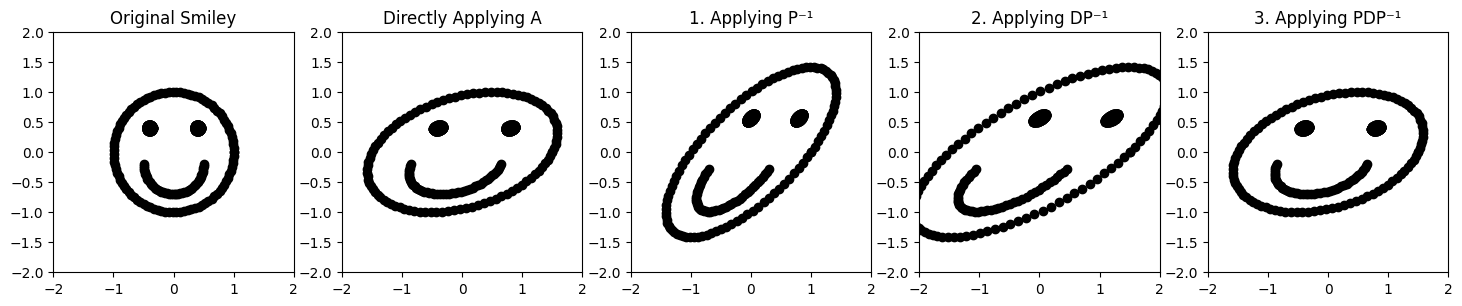

In [1]:
# --- Diagonalizable Matrix ---
A = np.array([[1.5, 0.5],
              [0, 1]])

# Compute Eigenvalues and Eigenvectors
eigvals, eigvecs = np.linalg.eig(A)
P = eigvecs
P_inv = np.linalg.inv(P)
D = np.diag(eigvals)

# --- Smiley Face Point Cloud ---
t = np.linspace(0, 2 * np.pi, 100)
face_x = np.cos(t)
face_y = np.sin(t)
left_eye_x = -0.4 + 0.05 * np.cos(t)
left_eye_y =  0.4 + 0.05 * np.sin(t)
right_eye_x = 0.4 + 0.05 * np.cos(t)
right_eye_y = 0.4 + 0.05 * np.sin(t)
smile_t = np.linspace(0, np.pi, 50)
smile_x = 0.5 * np.cos(smile_t)
smile_y = -0.5 * np.sin(smile_t) - 0.2

points = np.vstack((
    np.column_stack((face_x, face_y)),
    np.column_stack((left_eye_x, left_eye_y)),
    np.column_stack((right_eye_x, right_eye_y)),
    np.column_stack((smile_x, smile_y))
))

# --- Apply Transformations ---
points_A = (A @ points.T).T
points_Pinv = (P_inv @ points.T).T
points_Pinv_D = (D @ points_Pinv.T).T
points_Pinv_D_P = (P @ points_Pinv_D.T).T

# --- Plotting ---
fig, axes = plt.subplots(1, 5, figsize=(18, 6))

titles = ["Original Smiley", "Directly Applying A", "1. Applying P⁻¹", "2. Applying DP⁻¹", "3. Applying PDP⁻¹"]
point_sets = [points, points_A, points_Pinv, points_Pinv_D, points_Pinv_D_P]

for ax, title, pts in zip(axes, titles, point_sets):
    ax.scatter(pts[:, 0], pts[:, 1], color='black')
    ax.set_title(title)
    ax.set_xlim(-2, 2)
    ax.set_ylim(-2, 2)
    ax.set_aspect('equal')

plt.show()
